<a href="https://colab.research.google.com/github/AKookani/BrickwallCliffordCircuit/blob/main/Meeting_24_6_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stabilizer Formalism & Clifford Circuits

In [1]:
!pip install qiskit ipywidgets
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=384ebb20a7ebd660fc4b6313346ec76dfbfeda2a959013ce809680367ea0b352
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


## Explanation of Qiskit stablizer

`qiskit.quantum_info.StabilizerState` represents a **stabilizer quantum state** in Qiskit.

A stabilizer state is any quantum state that can be fully described by **Pauli stabilizers** instead of a full statevector. This makes operations on Clifford circuits very efficient.

Typical examples:

* $|0\rangle$
* $|+\rangle$
* Bell states

### Example 1: Create $|0\rangle$ stabilizer

In [2]:
from qiskit.quantum_info import StabilizerState, Statevector, SparsePauliOp

stabilizer_state = StabilizerState.from_stabilizer_list(["Z"]) #returns the state is stabilized by Z operator
print(stabilizer_state)

StabilizerState(['+Z'])


Here, `"Z"` means the state is stabilized by the Pauli (Z) operator:

$Z|0\rangle = |0\rangle$

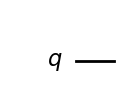

In [3]:
Clifford_circuit = stabilizer_state.clifford.to_circuit()
display(Clifford_circuit.draw('mpl'))

.clifford means What Clifford tableau internally represents this stabilizer state?

In [4]:
psi = Statevector.from_instruction(Clifford_circuit)
display(psi.draw('latex'))

<IPython.core.display.Latex object>

- **`Clifford`** — represents a Clifford *operation* (unitary). Internally it stores a tableau (symplectic matrix + phases) describing how that operation conjugates each Pauli generator. There's no "Clifford state" — `Clifford` is always an operator, never a state.
- **`StabilizerState`** — represents a stabilizer *state*. Internally it stores a `Clifford` object as its underlying data structure, but interprets it as: "the state obtained by applying this Clifford to $|0\rangle^{\otimes n}$." So a `StabilizerState`'s tableau is literally "what Pauli generators does $|0\rangle^{\otimes n}$ get mapped to" — i.e. the stabilizer generators of the resulting state.

In [5]:
psi = Statevector.from_label('0')
print(psi.expectation_value(SparsePauliOp('Z')))

(1+0j)


In [6]:
psi = Statevector.from_label('1')
print(psi.expectation_value(SparsePauliOp('Z')))

(-1+0j)


In [7]:
psi = Statevector.from_label('+')
print(psi.expectation_value(SparsePauliOp('Z')))

0j


### Example 2: Bell state

The Bell state

[
$\frac{|00\rangle + |11\rangle}{\sqrt2}$
]

is stabilized by

* (XX)
* (ZZ)

In [8]:
from qiskit.quantum_info import StabilizerState

bell = StabilizerState.from_stabilizer_list([
    "XX",
    "ZZ"
])

print(bell)

StabilizerState(['+XX', '+ZZ'])


### Example 3: From a Clifford circuit

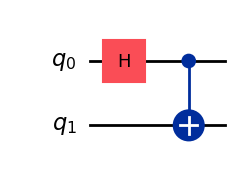

StabilizerState(['+XX', '+ZZ'])


In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
display(qc.draw('mpl'))

state = StabilizerState(qc)
print(state)

## Stabilizer State Efficiency

**When to use Stabilizer State**

Use `StabilizerState` when your circuit only contains **Clifford gates**, such as:

* H
* S
* X, Y, Z
* CNOT (CX)
* SWAP

It is **much more memory-efficient** than a full statevector for these circuits.

If your circuit contains non-Clifford gates like `T`, `CCX` (Toffoli, in general), or arbitrary rotations (`RX`, `RY`, `RZ` with arbitrary angles), then `StabilizerState` is generally not applicable, and you'd instead use something like `Statevector`.

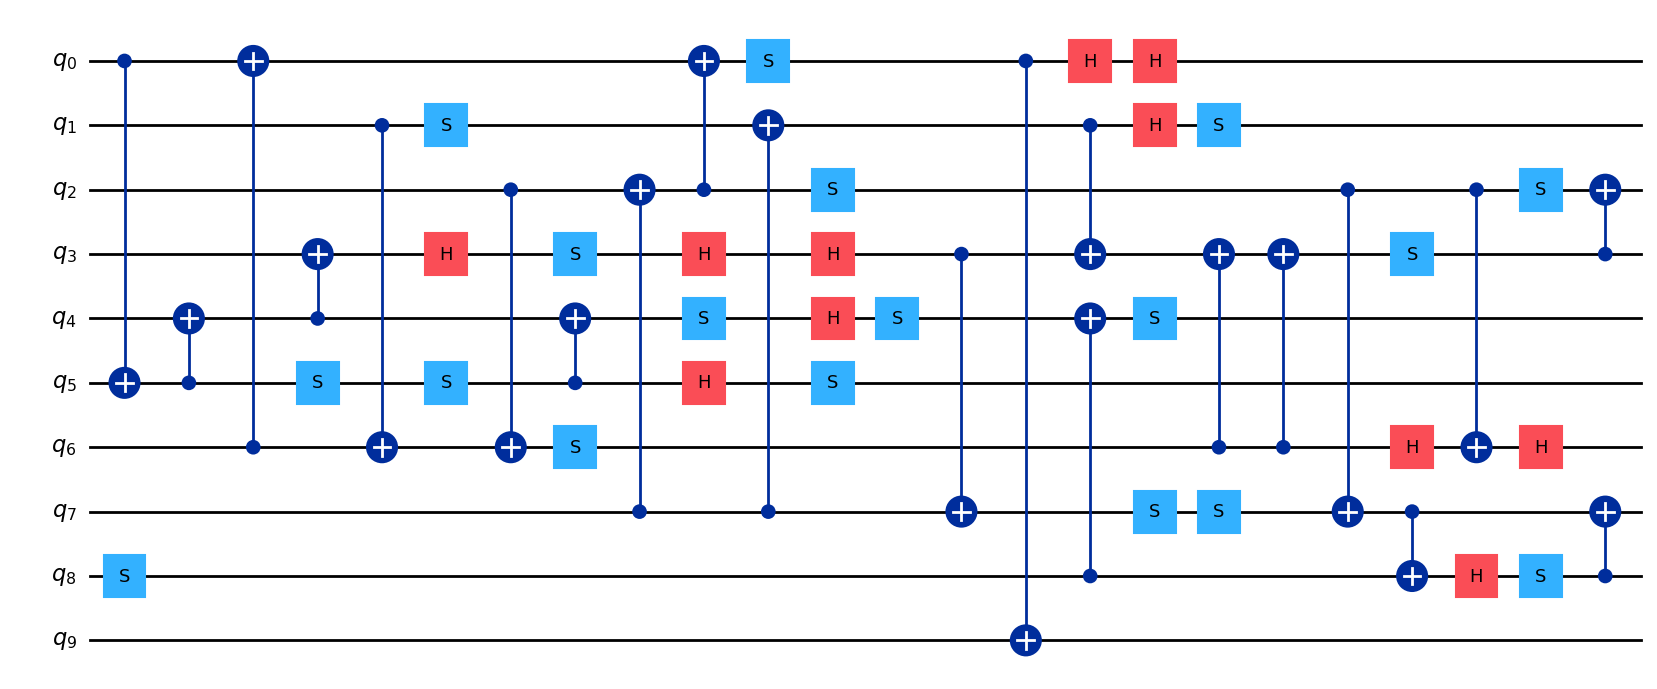

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState
import random

n = 10
qc = QuantumCircuit(n)

for _ in range(50):
    gate = random.choice(["h", "s", "cx"])

    if gate == "h":
        qc.h(random.randrange(n))

    elif gate == "s":
        qc.s(random.randrange(n))

    else:
        a, b = random.sample(range(n), 2)
        qc.cx(a, b)

qc.draw("mpl")

In [11]:
stab = StabilizerState(qc)

print(stab) #There will be 10 generators because we have 10 qubits.

StabilizerState(['+IIIZIIIIYZ', '+IZZIIIIZII', '+IZZIIIZIYI', '+IYZIYXXXYI', '-IXYIIXIIII', '+IIIZYIIIYZ', '+IIIZIIZZYI', '+IZZIIIIZYI', '+IXYIIIIIII', '+ZIIIIIIIIZ'])


In [12]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_instruction(qc)

psi.draw('latex')

<IPython.core.display.Latex object>

# Measurement-induced dynamics in **Clifford circuits** using the **stabilizer formalism**

**Projective measurements** simulation on **random Clifford ciruits** to measure **entanglement entropy** and **purification time**.

In [77]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.5 MB/s eta 0:00:00


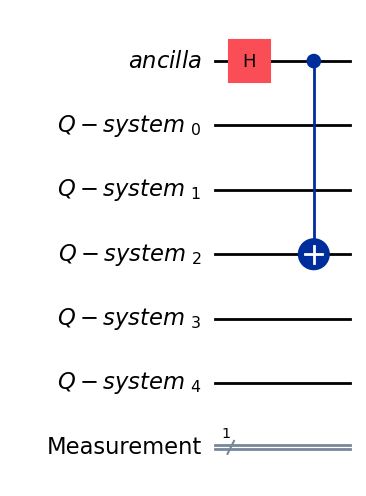

StabilizerState(['+IIXIIX', '+IIIIZI', '+IIIZII', '+IIZIIZ', '+IZIIII', '+ZIIIII'])


In [90]:
from qiskit.quantum_info import StabilizerState
from qiskit import QuantumRegister, ClassicalRegister

size = 5 # systems_size

Ancilla = QuantumRegister(1, 'ancilla ')
System = QuantumRegister(size, 'Q-system ')
Measure = ClassicalRegister(1, "Measurement")

qc_base = QuantumCircuit(Ancilla, System, Measure)

qc_base.h(Ancilla)
qc_base.cx(Ancilla, System[size // 2])
display(qc_base.draw('mpl'))

state = StabilizerState(qc_base)

print(state)

StabilizerState(['+IYZIIX', '-XZYIYI', '-IZYIII', '+IIYIIZ', '+IIIZII', '-ZIIIZI'])
Measured system_2 -> outcome 0
Aer: 1.00
t=0, S0=1.00, purity=0.50
StabilizerState(['-YIXIXX', '-IZIIII', '-YIZIZI', '+YIZIIZ', '+IIIZII', '+YZIIII'])
Measured system_4 -> outcome 1
Aer: 1.00
t=1, S0=1.00, purity=0.50
StabilizerState(['-IZIIII', '-ZIYYIX', '+ZZYYYI', '+IZXIZY', '+XZIZII', '+IZYIIX'])
Measured system_4 -> outcome 1
Aer: 1.00
t=2, S0=1.00, purity=0.50
Aer: 1.00
t=3, S0=1.00, purity=0.50
Aer: 1.00
t=4, S0=1.00, purity=0.50
Aer: 1.00
t=5, S0=1.00, purity=0.50
StabilizerState(['+XIIZYI', '-IIIZII', '-ZZZZZI', '+XIYIIY', '+IIYIYI', '+YYXZXI'])
Measured system_2 -> outcome 1
Aer: 0.00
t=6, S0=0.00, purity=1.00
StabilizerState(['-IIZIII', '+XIIZZI', '+ZZIZXI', '+XIZXXY', '+IIZYYI', '+ZYZYII'])
Measured system_3 -> outcome 1
Aer: 0.00
t=7, S0=0.00, purity=1.00
Aer: 0.00
t=8, S0=0.00, purity=1.00
StabilizerState(['+IIZIII', '+YZIYZI', '+XZZIXI', '+YIIXYY', '+IZIZXI', '+YXZXII'])
Measured system_3

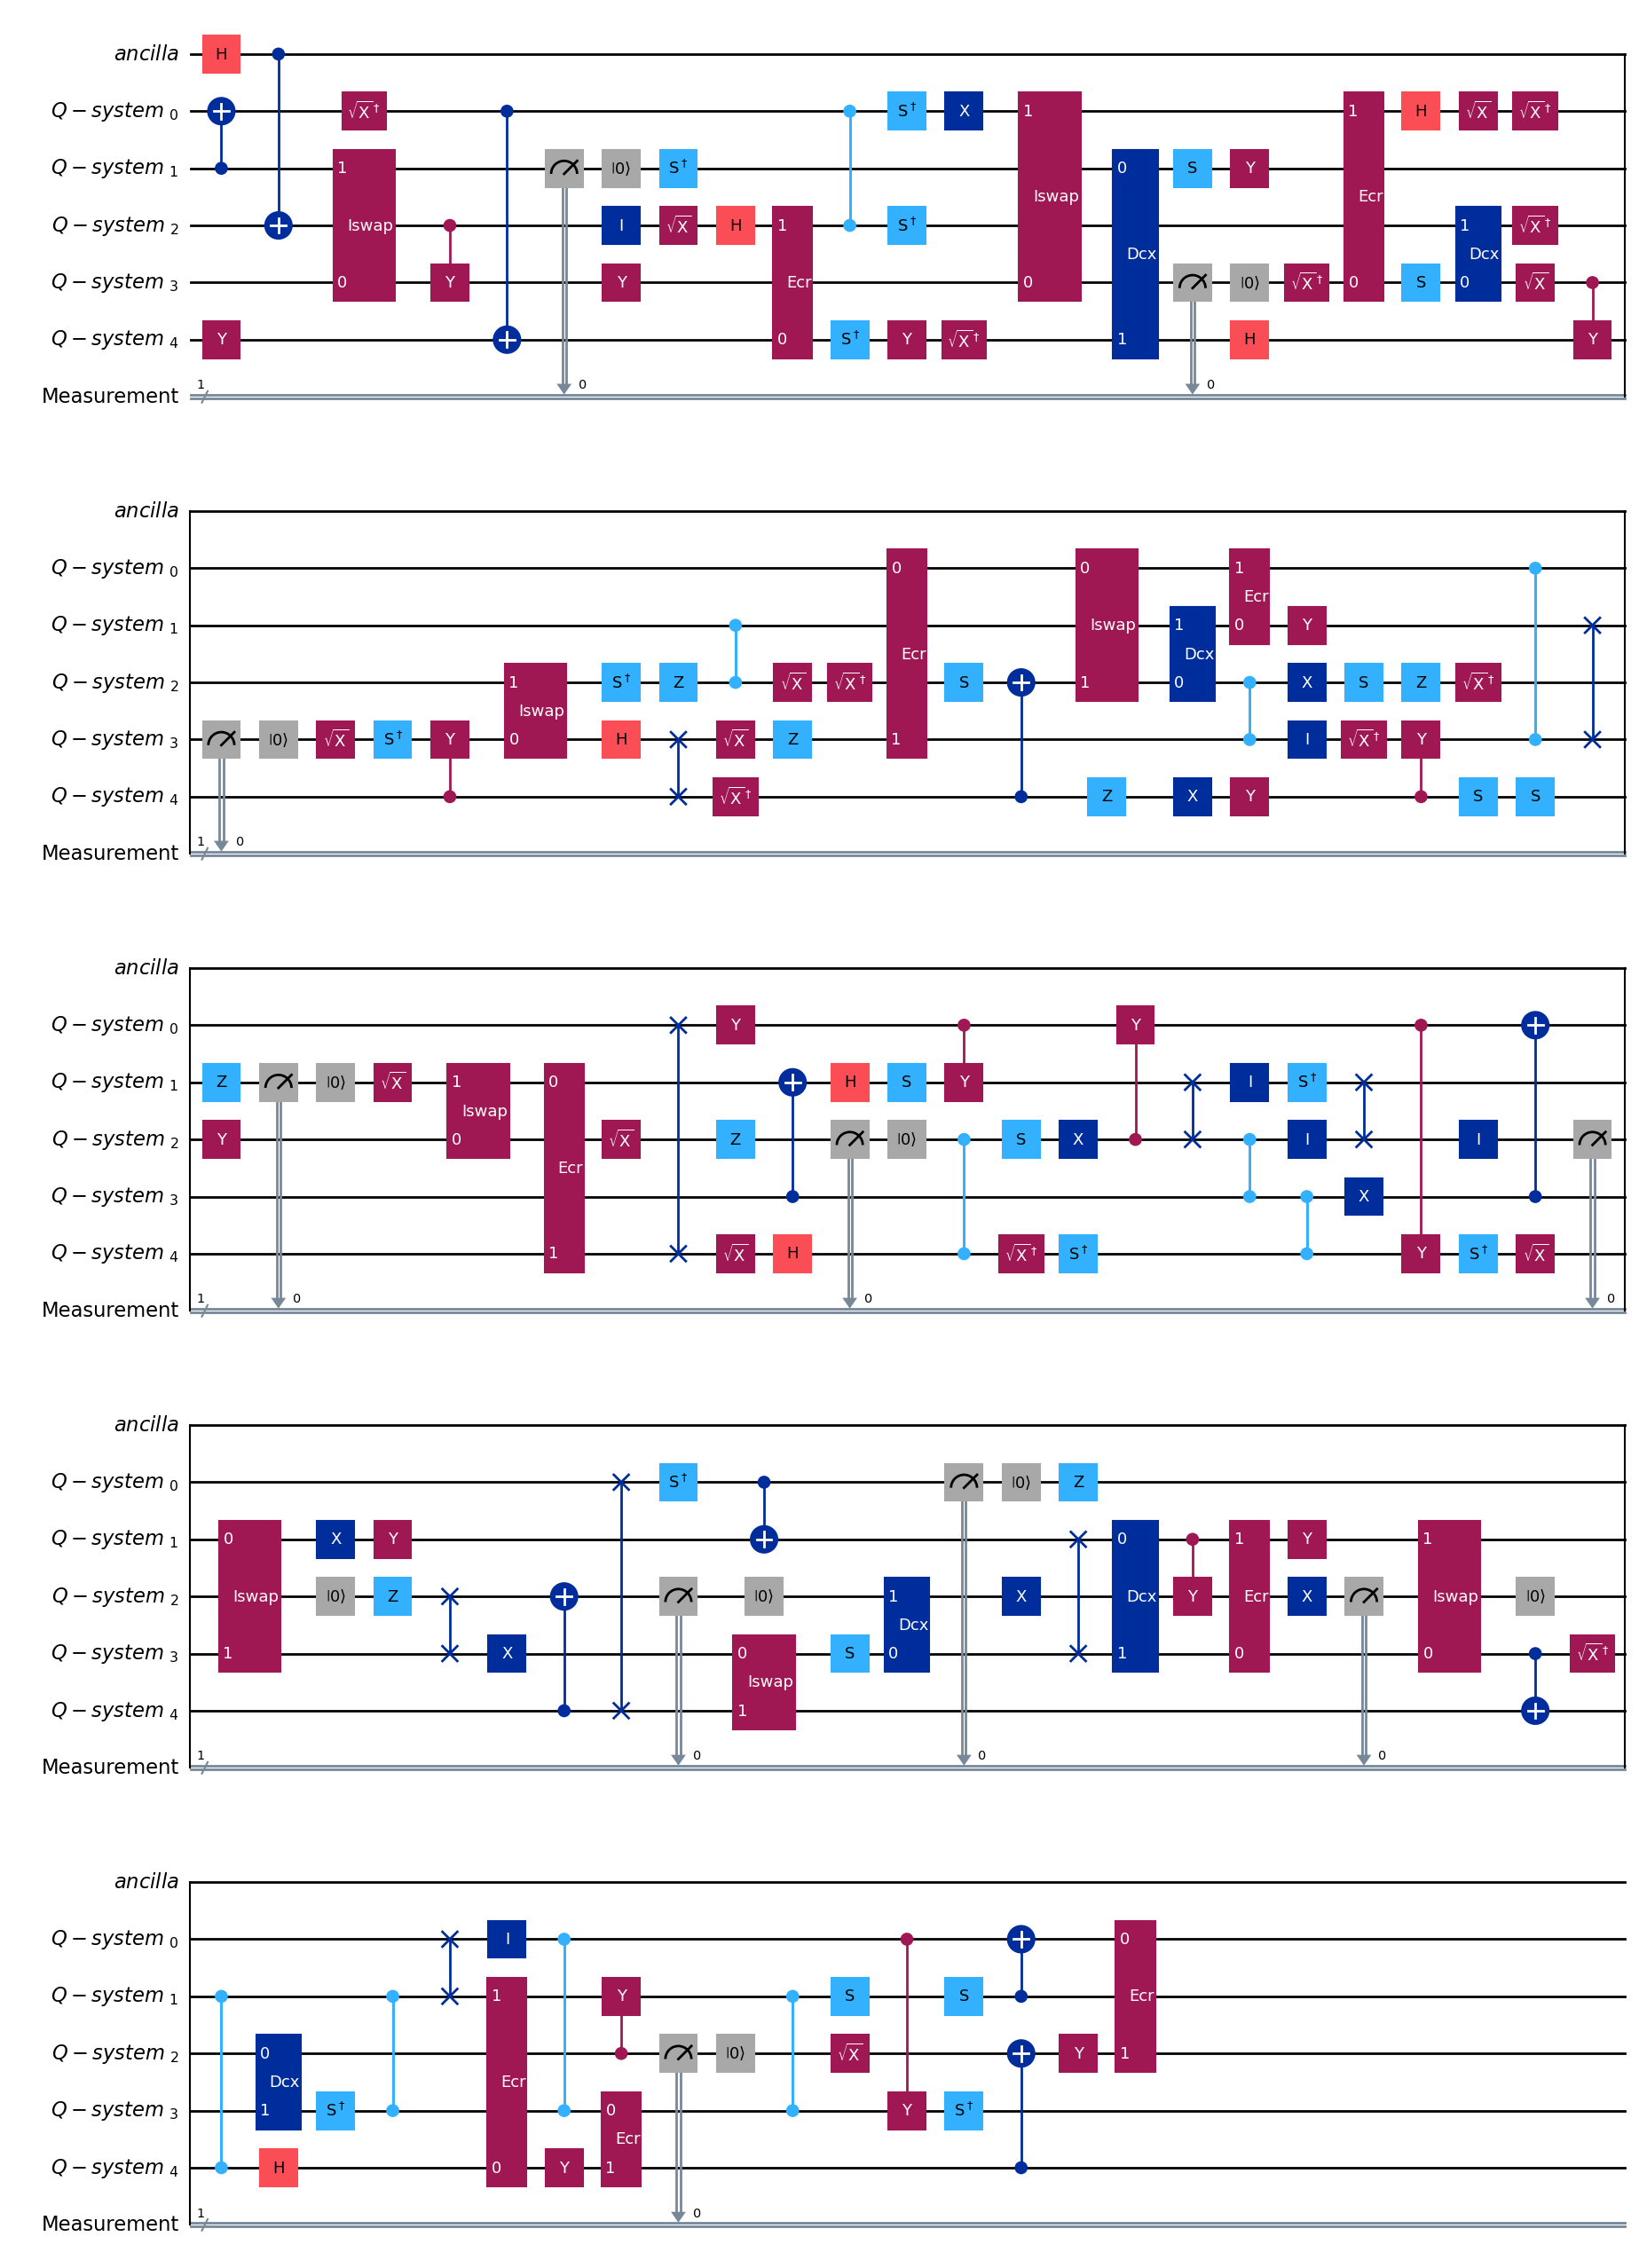

In [91]:
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Clifford
from qiskit.quantum_info import partial_trace, entropy, Statevector, purity, DensityMatrix
from qiskit.circuit.random import random_clifford_circuit
from qiskit_aer import AerSimulator
from qiskit import transpile


p_measure=0.6
T=15 #circuit depth

outcome = []
entropy_history = []
entropy_history_circ = []

rng = np.random.default_rng()
sim = AerSimulator(method='density_matrix')

#qc = QuantumCircuit(size,1)
# defining symbolic measurement gate
#measurement_gate = QuantumCircuit(1)
#measurement_gate.id(0)
#meas_gate = measurement_gate.to_gate(label='⟨ψ∣Z∣ψ⟩')

# Algorithm loop
for t in range(T):

    qc = random_clifford_circuit(num_qubits=size, num_gates=10)
    # gate = rng.choice(["H","S", "Z", "-S", "CX"])

    # if gate=="H":
    #     n = rng.integers(size)
    #     qc.h(n)
    #     qc.barrier([n])

    # elif gate=="S":
    #     n = rng.integers(size)
    #     qc.s(n)
    #     qc.barrier([n])

    # elif gate=="Z":
    #     n = rng.integers(size)
    #     qc.z(n)
    #     qc.barrier([n])

    # elif gate=="-S":
    #     n = rng.integers(size)
    #     qc.sdg(n)
    #     qc.barrier([n])

    # else:
    #     q1,q2 = rng.choice(size,2,replace=False)
    #     qc.cx(q1,q2)
    #     qc.barrier([q1,q2])

    qc_base = qc_base.compose(qc, qubits=System)

    state = state.evolve(Clifford(qc), qargs=list(range(1, size + 1)))

    #print(state == StabilizerState(qc_base)) # Temporary code to check if they match

    qc.clear()

    # Measuremnt part
    random = rng.random()
    if random < p_measure:
        q = rng.integers(1, size)

        # Circuite representation
        qc_base.measure(q, Measure[0])
        qc_base.reset(q)
        #qc.barrier([q])
        #qc_base = qc_base.compose(qc, qubits=System)
        #qc.clear()

        # Clifford representation
        outcom, state = state.measure([q]) #stabilizer method
        outcome.append(outcom)
        print(state)
        print(f"Measured system_{q} -> outcome {outcom}")

    # Circuite representation
    qc_sim = qc_base.copy()
    qc_sim.save_density_matrix()
    tqc = transpile(qc_sim, sim)
    result = sim.run(tqc, shots=1).result()
    rho_full = result.data(0)['density_matrix']
    rho_ancilla_circ = partial_trace(rho_full, list(range(1, size + 1)))
    S_circ = entropy(rho_ancilla_circ)
    print(f"Aer: {S_circ:.2f}")
    entropy_history_circ.append(S_circ)

    # Clifford representation
    rho_ancilla_stab = partial_trace(Statevector(state.clifford.to_circuit()), list(range(1, size + 1)))
    S = entropy(rho_ancilla_stab)
    entropy_history.append(S)  # <-- save it
    print(f"t={t}, S0={S:.2f}, purity={purity(rho_ancilla_stab).real:.2f}")

display(qc_base.draw('mpl'))

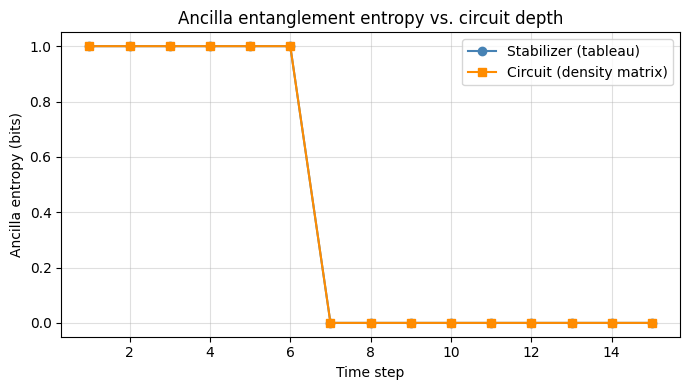

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, T + 1), entropy_history, marker='o', linewidth=1.5, color='steelblue', label='Stabilizer (tableau)')
plt.plot(range(1, T + 1), entropy_history_circ, marker='s', linewidth=1.5, color='darkorange', label='Circuit (density matrix)')
plt.xlabel("Time step")
plt.ylabel("Ancilla entropy (bits)")
plt.title("Ancilla entanglement entropy vs. circuit depth")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

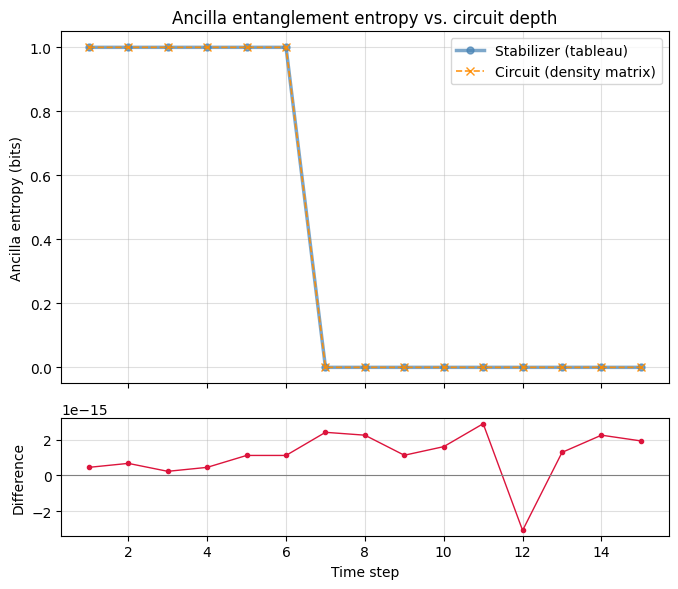

In [93]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})

# Top: both series, styled to stay visible when overlapping
ax1.plot(range(1, T + 1), entropy_history, marker='o', markersize=5,
          linewidth=2.5, color='steelblue', alpha=0.7, label='Stabilizer (tableau)')
ax1.plot(range(1, T + 1), entropy_history_circ, marker='x', markersize=6,
          linewidth=1.2, linestyle='--', color='darkorange', alpha=0.9, label='Circuit (density matrix)')
ax1.set_ylabel("Ancilla entropy (bits)")
ax1.set_title("Ancilla entanglement entropy vs. circuit depth")
ax1.legend()
ax1.grid(True, alpha=0.4)

# Bottom: difference between the two, to show how close they really are
diff = np.array(entropy_history) - np.array(entropy_history_circ)
ax2.plot(range(1, T + 1), diff, marker='.', color='crimson', linewidth=1)
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.set_xlabel("Time step")
ax2.set_ylabel("Difference")
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

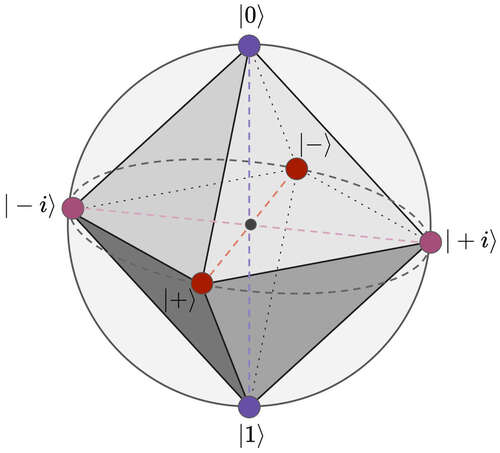

**The octahedron in the Bloch sphere defines the states accessible via single-qubit Clifford gates.**

$ZZZZ$ stabilizes $|0000\rangle$. So it's on of the $|0000\rangle$'s **stabilizers**. But it's not a **generator** of $|000\rangle$, because it's the product $Z_1 \cdot Z_2 \cdot Z_3 \cdot Z_4$ which is redundant and not independent.

Three simple conditions for a set to count as generators of an n-qubit state:

1. **They're real stabilizers.** Each one has to actually stabilize the state (give +1 when applied).

2. **None is redundant.** You can't build any one of them by multiplying the others together. Each one adds something new.

3. **There are exactly n of them.** For n qubits, you need exactly n generators — no more, no less.

That's it. Also worth knowing: the generator set isn't unique. For $|00\rangle$, $\{Z_1, Z_2\}$ works, but so does $\{Z_1, Z_1Z_2\}$ — different lists, same state, both valid.

**To turn the clifford tableau into a state vector, we need a circuit intermediary**